In [35]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

In [36]:
graph = nx.read_gexf("filtered_graph.gexf")
print(len(graph.nodes))
print(len(graph.edges))

26119
48949


In [37]:
to_plot = []

non_corresponding = 0

signs = [0, 0]

for u, v in graph.edges:
    if graph.has_edge(v, u):
        to_plot.append(abs(graph[u][v]["weight"] - graph[v][u]["weight"]))
        signs[int(np.sign(graph[u][v]["weight"]) == np.sign(graph[v][u]["weight"]))] += 1
    else:
        non_corresponding += 1

print(f"non_corresponding: {non_corresponding}")
print(f"diff_signs: {signs[0]}")
print(f"eq_signs: {signs[1]}")

non_corresponding: 33407
diff_signs: 2914
eq_signs: 12628


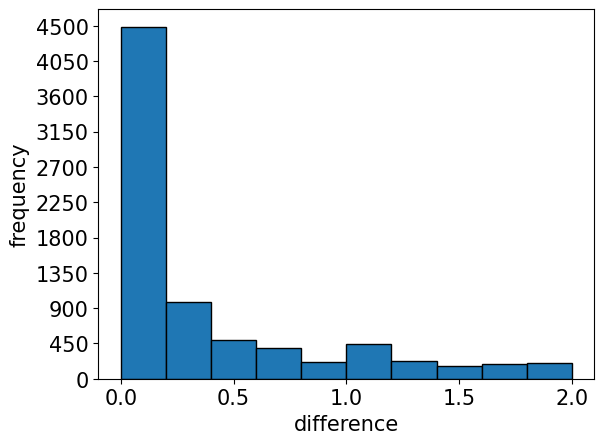

In [38]:
counts, bins = np.histogram(to_plot, bins=10)
counts = counts / 2

plt.hist(bins[:-1], bins, weights=counts, edgecolor="black")

plt.xlabel("difference", fontsize=15)
plt.ylabel("frequency", fontsize=15)
plt.yticks(np.linspace(0, 4500, 11))
plt.tick_params(axis="both", labelsize=15)
plt.show()

In [39]:
discarded = 0

undirected_graph = nx.Graph()

for u, v in graph.edges:
    if not graph.has_edge(v, u):
        undirected_graph.add_edge(u, v, weight=graph[u][v]["weight"])
    elif np.sign(graph[u][v]["weight"]) == np.sign(graph[v][u]["weight"]):
        undirected_graph.add_edge(u, v, weight=np.mean([graph[u][v]["weight"], graph[v][u]["weight"]]))
    else:
        discarded += 1

discarded
    

2914

In [40]:
nx.write_gexf(undirected_graph, "undirected_graph.gexf")